In [67]:
#step 1: Import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

In [68]:
#creating a folder to store all the plots
plot_dir = "plots"
os.makedirs(plot_dir,exist_ok=True)

In [69]:
#load the dataset
df = pd.read_csv("cleaned_HR_Attrition.csv")

In [70]:
#basic data information
print(df.info())
print(df.head())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [71]:
#updating the column's name to more readable and easy handling format.
import re
columns = df.columns
new_snake_case_columns = [re.sub(r'(?<!^)(?=[A-Z])', '_', col).lower() for col in columns]
df.columns = new_snake_case_columns
print(df.columns)

Index(['age', 'attrition', 'business_travel', 'daily_rate', 'department',
       'distance_from_home', 'education', 'education_field', 'employee_count',
       'employee_number', 'environment_satisfaction', 'gender', 'hourly_rate',
       'job_involvement', 'job_level', 'job_role', 'job_satisfaction',
       'marital_status', 'monthly_income', 'monthly_rate',
       'num_companies_worked', 'over18', 'over_time', 'percent_salary_hike',
       'performance_rating', 'relationship_satisfaction', 'standard_hours',
       'stock_option_level', 'total_working_years', 'training_times_last_year',
       'work_life_balance', 'years_at_company', 'years_in_current_role',
       'years_since_last_promotion', 'years_with_curr_manager'],
      dtype='object')


In [72]:
#step 2:analyse employee attrition
print(df["attrition"].value_counts())

attrition
No     1233
Yes     237
Name: count, dtype: int64


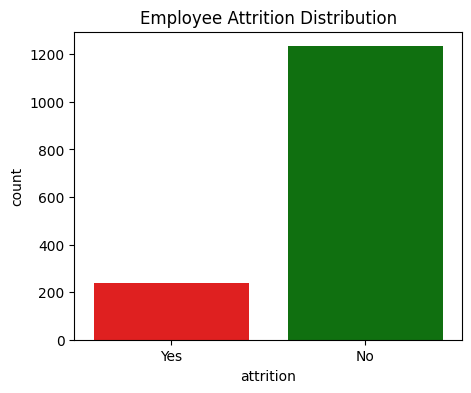

In [73]:
#visulize attrition distribution
plt.figure(figsize=(5,4))
sns.countplot(x="attrition", data = df, hue= "attrition",palette=['red','green'])
plt.title("Employee Attrition Distribution")
plt.savefig(f"{plot_dir}/attrition_distribution.png")
plt.show()

attrition
No     37.561233
Yes    33.607595
Name: age, dtype: float64


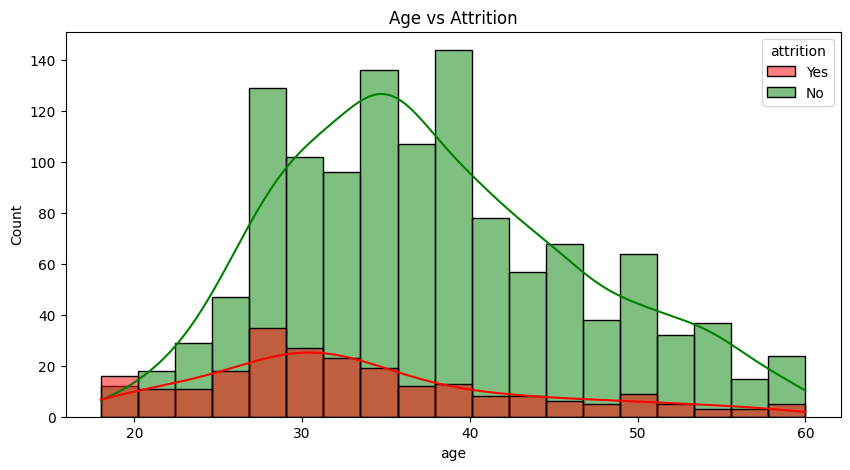

In [74]:
#step 3:factors affecting attrition
# 3.1: Age vs Attrition
print(df.groupby('attrition')['age'].mean())
plt.figure(figsize=(10,5))
sns.histplot(data = df,x= 'age', hue = 'attrition', kde = True, palette=['red','green'])
plt.title("Age vs Attrition")
plt.savefig(f"{plot_dir}/ age_vs_attrition.png")
plt.show()


job_role                   attrition
Healthcare Representative  No           0.931298
                           Yes          0.068702
Human Resources            No           0.769231
                           Yes          0.230769
Laboratory Technician      No           0.760618
                           Yes          0.239382
Manager                    No           0.950980
                           Yes          0.049020
Manufacturing Director     No           0.931034
                           Yes          0.068966
Research Director          No           0.975000
                           Yes          0.025000
Research Scientist         No           0.839041
                           Yes          0.160959
Sales Executive            No           0.825153
                           Yes          0.174847
Sales Representative       No           0.602410
                           Yes          0.397590
Name: proportion, dtype: float64


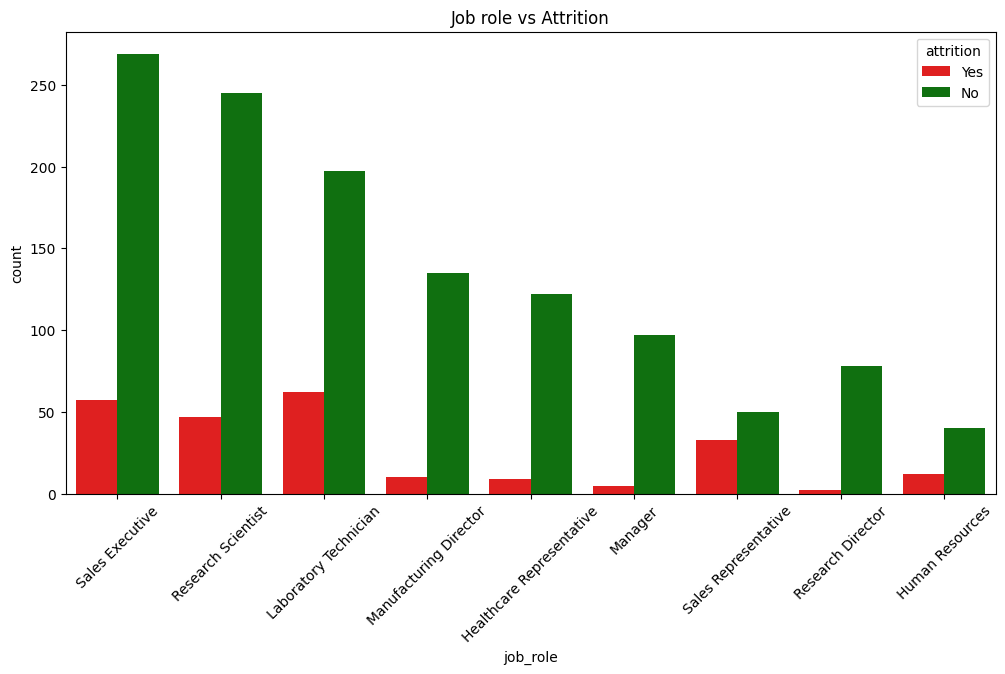

In [75]:
#3.2: job role vs attrition
print(df.groupby("job_role")["attrition"].value_counts(normalize = True))
plt.figure(figsize=(12,6))
sns.countplot(data = df, x = "job_role", hue = "attrition", palette=['red','green'])
plt.xticks(rotation = 45)
plt.title("Job role vs Attrition")
plt.savefig(f"{plot_dir}/jobrole_vs_attrition.png")
plt.show()

attrition
No     5204.0
Yes    3202.0
Name: monthly_income, dtype: float64


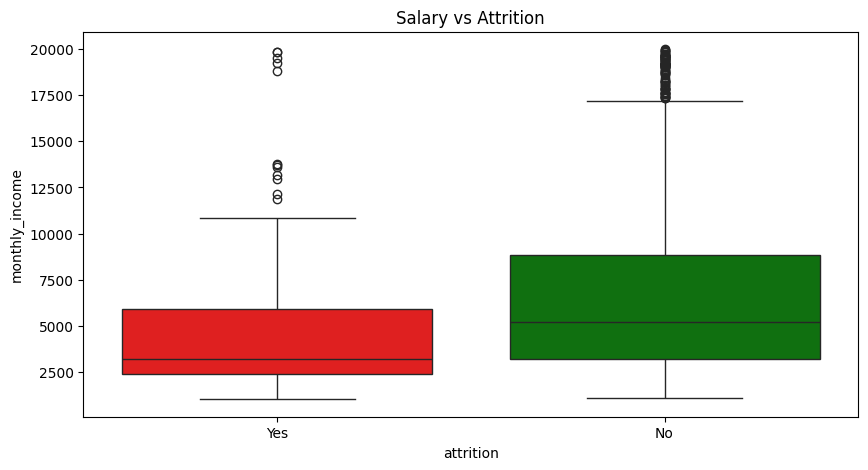

In [76]:
#3.3: Income vs Attrition
print(df.groupby("attrition")["monthly_income"].median())
plt.figure(figsize = (10,5))
sns.boxplot(data = df, x = 'attrition', y = 'monthly_income', hue = 'attrition' ,palette=['red','green'])
plt.title('Salary vs Attrition')
plt.savefig(f"{plot_dir}/salary_vs_attrition.png")
plt.show()

attrition
No     7.0
Yes    9.0
Name: distance_from_home, dtype: float64


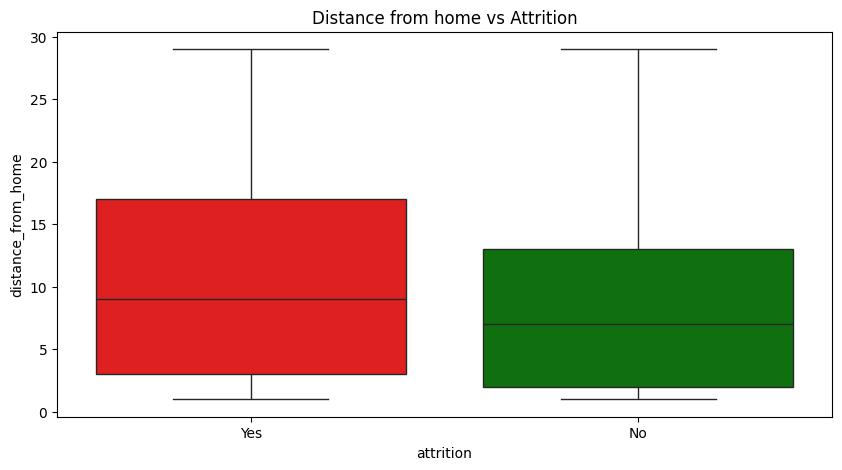

In [77]:
#3.4: distance from home vs attrition
print(df.groupby('attrition')['distance_from_home'].median())
plt.figure(figsize=(10,5))
sns.boxplot(data = df, x = 'attrition', y = 'distance_from_home', hue = 'attrition', palette=['red','green'])
plt.title('Distance from home vs Attrition')
plt.savefig(f"{plot_dir}/distance_vs_attrition.png")
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

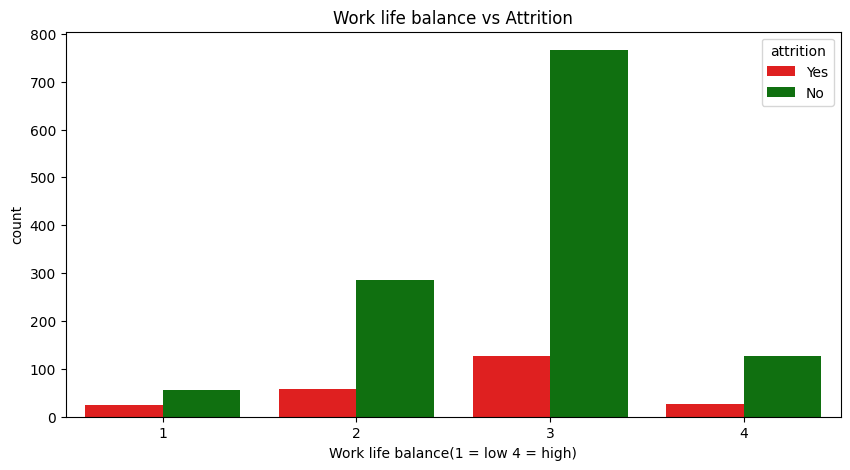

In [78]:
#step 4: Advance insights.
#4.1: work life balance vs attrition
plt.figure(figsize = (10,5))
sns.countplot(data = df, x = 'work_life_balance', hue = 'attrition', palette=['red','green'])
plt.title('Work life balance vs Attrition')
plt.xlabel('Work life balance(1 = low 4 = high)')
plt.savefig(f"{plot_dir}/work_life_vs_attrition.png")
plt.show


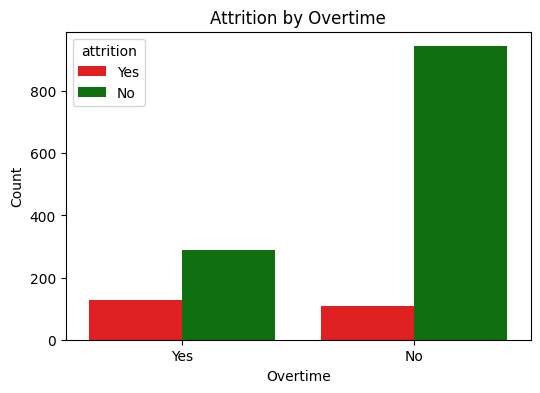

In [79]:
#4.2 overtime vs attrition
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="over_time", hue="attrition", palette=["red", "green"])
plt.title("Attrition by Overtime")
plt.xlabel("Overtime")
plt.ylabel("Count")
plt.savefig(f"{plot_dir}/overtime_vs_attrition.png")
plt.show()

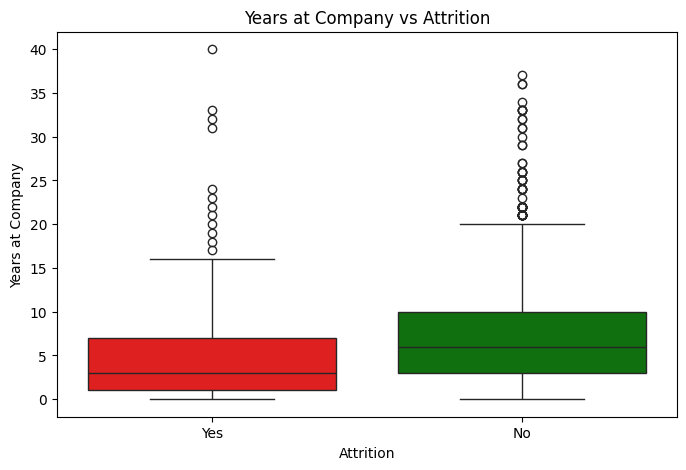

In [80]:
#4.3 Years at Company vs Attrition
plt.figure(figsize=(8, 5))
sns.boxplot(x="attrition", y="years_at_company", data=df, hue = "attrition", palette=["red", "green"])
plt.title("Years at Company vs Attrition")
plt.xlabel("Attrition")
plt.ylabel("Years at Company")
plt.savefig(f"{plot_dir}/years_at_company_vs_attrition.png")
plt.show()

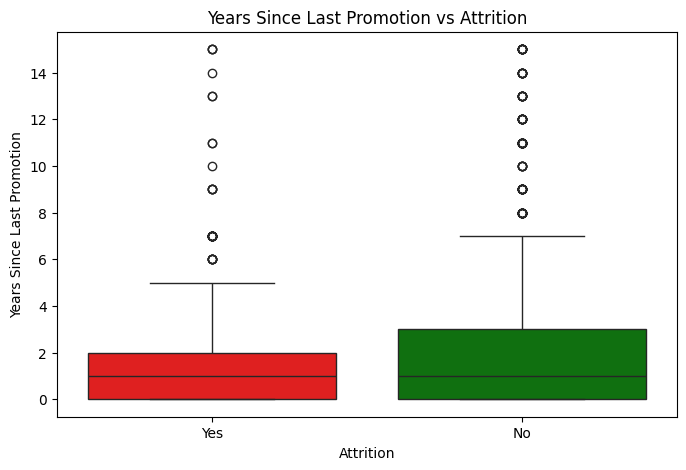

In [81]:
#4.4 Promotion & Career Growth
plt.figure(figsize=(8, 5))
sns.boxplot(x="attrition", y="years_since_last_promotion", data=df, hue = "attrition", palette=["red", "green"])
plt.title("Years Since Last Promotion vs Attrition")
plt.xlabel("Attrition")
plt.ylabel("Years Since Last Promotion")
plt.savefig(f"{plot_dir}/promotion_vs_attrition.png")
plt.show()


In [82]:
#Step 5: Summary & Next Steps
print("\n Key Insights:")
print("1.️ Employees with poor work-life balance leave more.")
print("2.️ Overtime workers have a higher attrition rate.")
print("3. New employees (0-3 years) leave more.")
print("4. Lack of promotion leads to higher attrition.")

print("\n Recommendations for HR:")
print("✔ Improve work-life balance policies.")
print("✔ Reduce excessive overtime.")
print("✔ Strengthen employee onboarding programs.")
print("✔ Focus on career growth opportunities.")


 Key Insights:
1.️ Employees with poor work-life balance leave more.
2.️ Overtime workers have a higher attrition rate.
3. New employees (0-3 years) leave more.
4. Lack of promotion leads to higher attrition.

 Recommendations for HR:
✔ Improve work-life balance policies.
✔ Reduce excessive overtime.
✔ Strengthen employee onboarding programs.
✔ Focus on career growth opportunities.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')